## Importing Necessary Libraries

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
from google.colab import files
uploaded = files.upload()
!apt-get install -y fonts-liberation

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


### Setting Theme

In [35]:
sns.set_theme()
sns.set_theme(context='notebook',style='whitegrid',palette='viridis',font='Liberation Serif',font_scale=1,color_codes=True)


## Functions Definition

In [36]:
def sequence_composition(sequence:str)  -> np.ndarray[np.float64]:
  sequence = sequence[:40]
  alphabet = "AQLSREKTNGMWDHFYCIPV"
  composition_matrix = np.zeros((20,40))
  composition_vector = np.zeros((20))
  for i in range(len(alphabet)):
    for j in range(len(sequence)):
      if alphabet[i] == sequence[j]:
        composition_matrix[i][j] += 1
        composition_vector[i] += composition_matrix[i][j]
  composition_vector = composition_vector/40
  return composition_vector

def hp_ai(sequence:str, window_size:int = 6 ) -> np.ndarray[np.float64]:
  kd_scale = {
    'R': -4.5,  # Arg
    'K': -3.9,  # Lys
    'N': -3.5,  # Asn
    'D': -3.5,  # Asp
    'Q': -3.5,  # Gln
    'E': -3.5,  # Glu
    'H': -3.2,  # His
    'P': -1.6,  # Pro
    'Y': -1.3,  # Tyr
    'W': -0.9,  # Trp
    'S': -0.8,  # Ser
    'T': -0.7,  # Thr
    'G': -0.4,  # Gly
    'A':  1.8,  # Ala
    'M':  1.9,  # Met
    'C':  2.5,  # Cys
    'F':  2.8,  # Phe
    'L':  3.8,  # Leu
    'V':  4.2,  # Val
    'I':  4.5   # Ile
    }

  a = 2.9 # relative volume of valine
  b = 3.9 # relative volume leucine/isoleucine

  sequence = sequence[:40]
  # padding to have as many scores as residues  (each window refers to the central res)
  d = int(window_size/2)
  sequence = "X"*d + sequence + "X"*d #padding
  hydrophobicities = np.array([])
  AIs = np.array([])  #aliphatic indexes
  for i in range(len(sequence)-(window_size)+1):
      counts_A = 0
      counts_V = 0
      counts_I = 0
      counts_L = 0
      hydrophobicity_score = 0
      window = sequence[i:i+window_size]
      for j in range(window_size):
        if window[j] != "X":
          hydrophobicity_score = (hydrophobicity_score + kd_scale[window[j]])
          if window[j] == 'A':
              counts_A += 1
          elif window[j] == 'V':
              counts_V += 1
          elif window[j] == 'I':
              counts_I += 1
          elif window[j] == 'L':
                counts_L += 1
      X_A = (counts_A / window_size)
      X_V = (counts_V / window_size)
      X_I = (counts_I / window_size)
      X_L = (counts_L / window_size)
      AI = X_A + a * X_V + b * (X_I + X_L) #Aliphatic Index Formula
      hydrophobicities = np.append(hydrophobicities, hydrophobicity_score / window_size)
      AIs = np.append(AIs, AI)
  H_AI = np.array([hydrophobicities.mean(), hydrophobicities.max(), np.argmax(hydrophobicities), AIs.mean(), AIs.max(), np.argmax(AIs)])
  return H_AI  #hydrophobicity and aliphatic index alltogether


def SSE(sequence,window_size):
  alpha_helix_scale = {
      "G": 0.570,  # Gly
      "P": 0.570,  # Pro
      "Y": 0.690,  # Tyr
      "C": 0.700,  # Cys
      "S": 0.770,  # Ser
      "T": 0.830,  # Thr
      "N": 0.670,  # Asn
      "R": 0.980,  # Arg
      "H": 1.000,  # His
      "D": 1.010,  # Asp
      "I": 1.080,  # Ile
      "W": 1.080,  # Trp
      "Q": 1.110,  # Gln
      "F": 1.130,  # Phe
      "K": 1.160,  # Lys
      "V": 1.060,  # Val
      "L": 1.210,  # Leu
      "A": 1.420,  # Ala
      "M": 1.450,  # Met
      "E": 1.510   # Glu
  }
  beta_sheet_scale = {
      "E": 0.370,  # Glu
      "D": 0.540,  # Asp
      "P": 0.550,  # Pro
      "G": 0.750,  # Gly
      "S": 0.750,  # Ser
      "K": 0.740,  # Lys
      "H": 0.870,  # His
      "N": 0.890,  # Asn
      "R": 0.930,  # Arg
      "A": 0.830,  # Ala
      "M": 1.050,  # Met
      "Q": 1.100,  # Gln
      "C": 1.190,  # Cys
      "T": 1.190,  # Thr
      "L": 1.300,  # Leu
      "F": 1.380,  # Phe
      "W": 1.370,  # Trp
      "Y": 1.470,  # Tyr
      "I": 1.600,  # Ile
      "V": 1.700   # Val
  }
  sequence = sequence[:40]
  # padding to have as many scores as residues (each window refers to the central res)
  d = int(window_size/2)
  sequence = "X"*d + sequence + "X"*d #padding
  alpha_helix = np.array([])
  beta_sheet = np.array([])
  for i in range(len(sequence)-(window_size)+1):
      alpha_score = 0
      beta_score = 0
      window = sequence[i:i+window_size]
      for j in range(window_size):
        w = 1 - abs(j - (window_size - 1)/2) / ((window_size - 1)/2)
        if window[j] != "X":
          alpha_score = alpha_score + w * alpha_helix_scale[window[j]]
          beta_score = beta_score + w * beta_sheet_scale[window[j]]
      alpha_helix = np.append(alpha_helix, alpha_score / window_size)
      beta_sheet = np.append(beta_sheet, beta_score / window_size)
  alpha_feature = np.array([alpha_helix.mean(), alpha_helix.max(), np.argmax(alpha_helix)])
  beta_feature = np.array([beta_sheet.mean(), beta_sheet.max(), np.argmax(beta_sheet)])
  return alpha_helix, alpha_feature, beta_sheet, beta_feature

def charge_seq(sequence, window_size):
  res_charges = {
        'K': 1,   # Lys
        'R': 1,   # Arg
        'H': 0.5, # His (partial positive)
        'D': -1,  # Asp
        'E': -1   # Glu
    }

  sequence = sequence[:20]
  # padding to have as many scores as residues  (each window refers to the central res)
  d = int(window_size/2)
  sequence = "X"*d + sequence + "X"*d #padding

  norm_charges = np.array([])

  for i in range(len(sequence)-(window_size)+1):
      charge = 0
      window = sequence[i:i+window_size]
      for j in range(window_size):
        if window[j] != "X" and window[j] in res_charges:
          charge = (charge + res_charges[window[j]])
      norm_charges = np.append(norm_charges, charge / window_size)
  charge_feature = np.array([norm_charges.max(), np.argmax(norm_charges), norm_charges.min(), np.argmin(norm_charges)])
  return norm_charges, charge_feature


def tm_helix_propensity(sequence: str, window_size: int = 7) -> np.ndarray[np.float64]:
    #TM Helix Propensity Scale (ProParam)
    tm_helix_propensity_scale = {
        'F':  1.980,
        'I':  1.970,
        'L':  1.820,
        'W':  1.530,
        'V':  1.460,
        'M':  1.400,
        'Y':  0.490,
        'A':  0.380,
        'G': -0.190,
        'C': -0.300,
        'T': -0.320,
        'S': -0.530,
        'H': -1.440,
        'P': -1.440,
        'N': -1.620,
        'Q': -1.840,
        'R': -2.570,
        'E': -2.900,
        'D': -3.270,
        'K': -3.460
    }

    sequence = sequence[:80]

    d = int(window_size / 2)     #Padding
    sequence = "X" * d + sequence + "X" * d

    tm_scores = np.array([])

    for i in range(len(sequence) - window_size + 1):
        score = 0.0
        window = sequence[i:i + window_size]

        for j in range(window_size):   #Weighted average
            w = 1 - abs(j - (window_size - 1) / 2) / ((window_size - 1) / 2)
            if window[j] in tm_helix_propensity_scale:
                score += w * tm_helix_propensity_scale[window[j]]
        tm_scores = np.append(tm_scores, score / window_size)

    tm_feature = np.array([
        tm_scores.mean(),        #mean score across sequence
        tm_scores.max(),         #max score
        np.argmax(tm_scores)     #position of max
    ])

    return tm_scores, tm_feature

def extract_features(seqs):
  num_seqs = len(seqs)
  hyd_ali = np.zeros([num_seqs, 6])
  tm = np.zeros([num_seqs, 3])
  a = np.zeros([num_seqs, 3])
  b = np.zeros([num_seqs, 3])
  c = np.zeros([num_seqs, 4])

  for row, seq in enumerate(seqs):
    hyd_ali_index = hp_ai(seq)
    _, alpha, _, beta = SSE(seq, window_size=9)
    _, charges = charge_seq(seq, window_size=3)
    _, tm_propensity = tm_helix_propensity(seq, window_size=7)
    hyd_ali[row] = hyd_ali_index
    tm[row] = tm_propensity
    a[row] = alpha
    b[row] = beta
    c[row] = charges
  return hyd_ali, tm, a, b, c


## Loading Data and Metadata

In [37]:
# load metadata file and SVM results file
metadata = pd.read_csv("data.tsv", sep = "\t")
svm = pd.read_csv("results_SVM.tsv", sep = "\t")
# extract dataframes for false positives and false negatives
FP = svm[(svm["Class"] == 0) & (svm["Prediction"] == 1)]
TP = svm[(svm["Class"] == 1) & (svm["Prediction"] == 1)]
FN = svm[(svm["Class"] == 1) & (svm["Prediction"] == 0)]
TN = svm[(svm["Class"] == 0) & (svm["Prediction"] == 0)]

fp_ids = FP["UniProt_ID"]
fn_ids = FN["UniProt_ID"]

fp_meta = metadata[metadata["UniProt_ID"].isin(fp_ids)]
fn_meta = metadata[metadata["UniProt_ID"].isin(fn_ids)]

## Plotting False Positives and False Negatives Kingdom Distribution

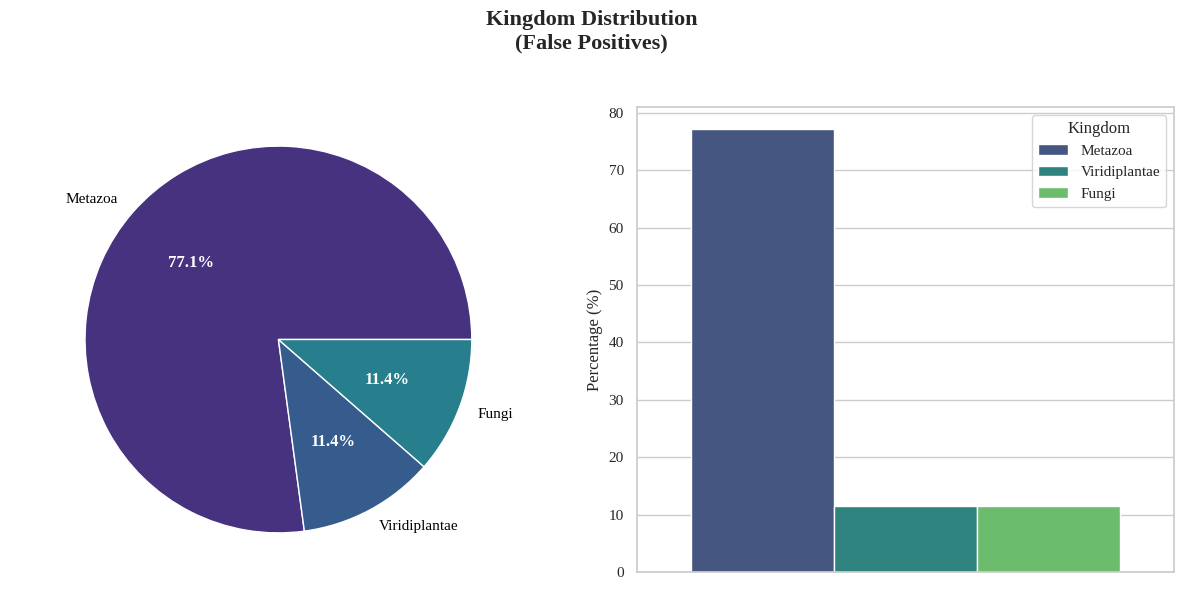

<Figure size 640x480 with 0 Axes>

In [52]:
#Count the values and percentages
fp_kingdom = fp_meta['Kingdom'].value_counts()
fp_percent = fp_kingdom / fp_kingdom.sum() * 100

#Divide the plot in two
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Kingdom Distribution\n(False Positives)", fontsize=16, fontweight='bold')

#Create the pie plot and format the labels
wedges, texts, autotexts = ax1.pie(fp_kingdom, labels=fp_kingdom.index, autopct='%.1f%%',)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

#Create the bar plot
sns.barplot(hue=fp_percent.index, y=fp_percent.values, legend=True, ax=ax2, palette="viridis", native_scale=True)
ax2.set_ylabel("Percentage (%)")

#Display the plots
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
plt.savefig("FP_kingdom.png", dpi=1000, format="png")
plt.clf()

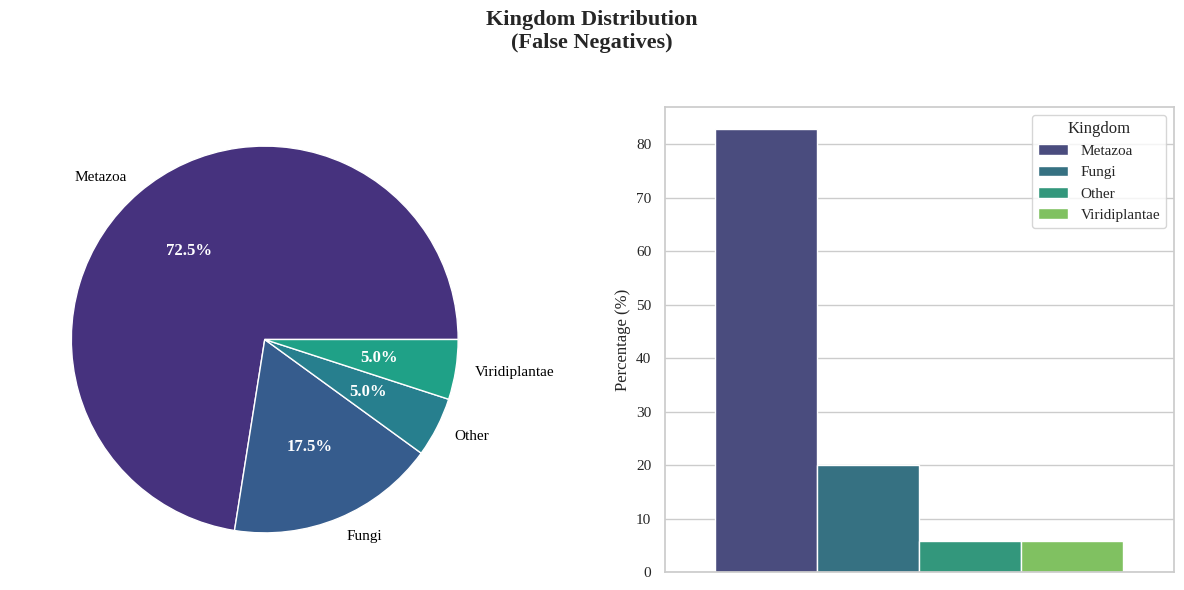

<Figure size 1200x600 with 0 Axes>

In [53]:
#Count the values and percentages
fn_kingdom = fn_meta['Kingdom'].value_counts()
fn_percent = fn_kingdom / fp_kingdom.sum() * 100

#Divide the plot in two
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Kingdom Distribution\n(False Negatives)", fontsize=16, fontweight='bold')

#Create the pie plot and format the labels
wedges, texts, autotexts = ax1.pie(fn_kingdom, labels=fn_kingdom.index, autopct='%.1f%%',)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

#Create the bar plot
sns.barplot(hue=fn_percent.index, y=fn_percent.values, legend=True, ax=ax2, palette="viridis", native_scale=True)
ax2.set_ylabel("Percentage (%)")

#Display the plots
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#Divide the plot in two
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Kingdom Distribution\n(False Negatives)", fontsize=16, fontweight='bold')

#Create the pie plot and format the labels
wedges, texts, autotexts = ax1.pie(fn_kingdom, labels=fn_kingdom.index, autopct='%.1f%%',)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

#Create the bar plot
sns.barplot(hue=fn_percent.index, y=fn_percent.values, legend=True, ax=ax2, palette="viridis", native_scale=True)
ax2.set_ylabel("Percentage (%)")

#Save the plots
plt.savefig("FN_kingdom.png", dpi=1000, format="png")
plt.clf()

## Plotting False Positives and False Negatives Species Distribution

/tmp/ipython-input-800681338.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-800681338.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


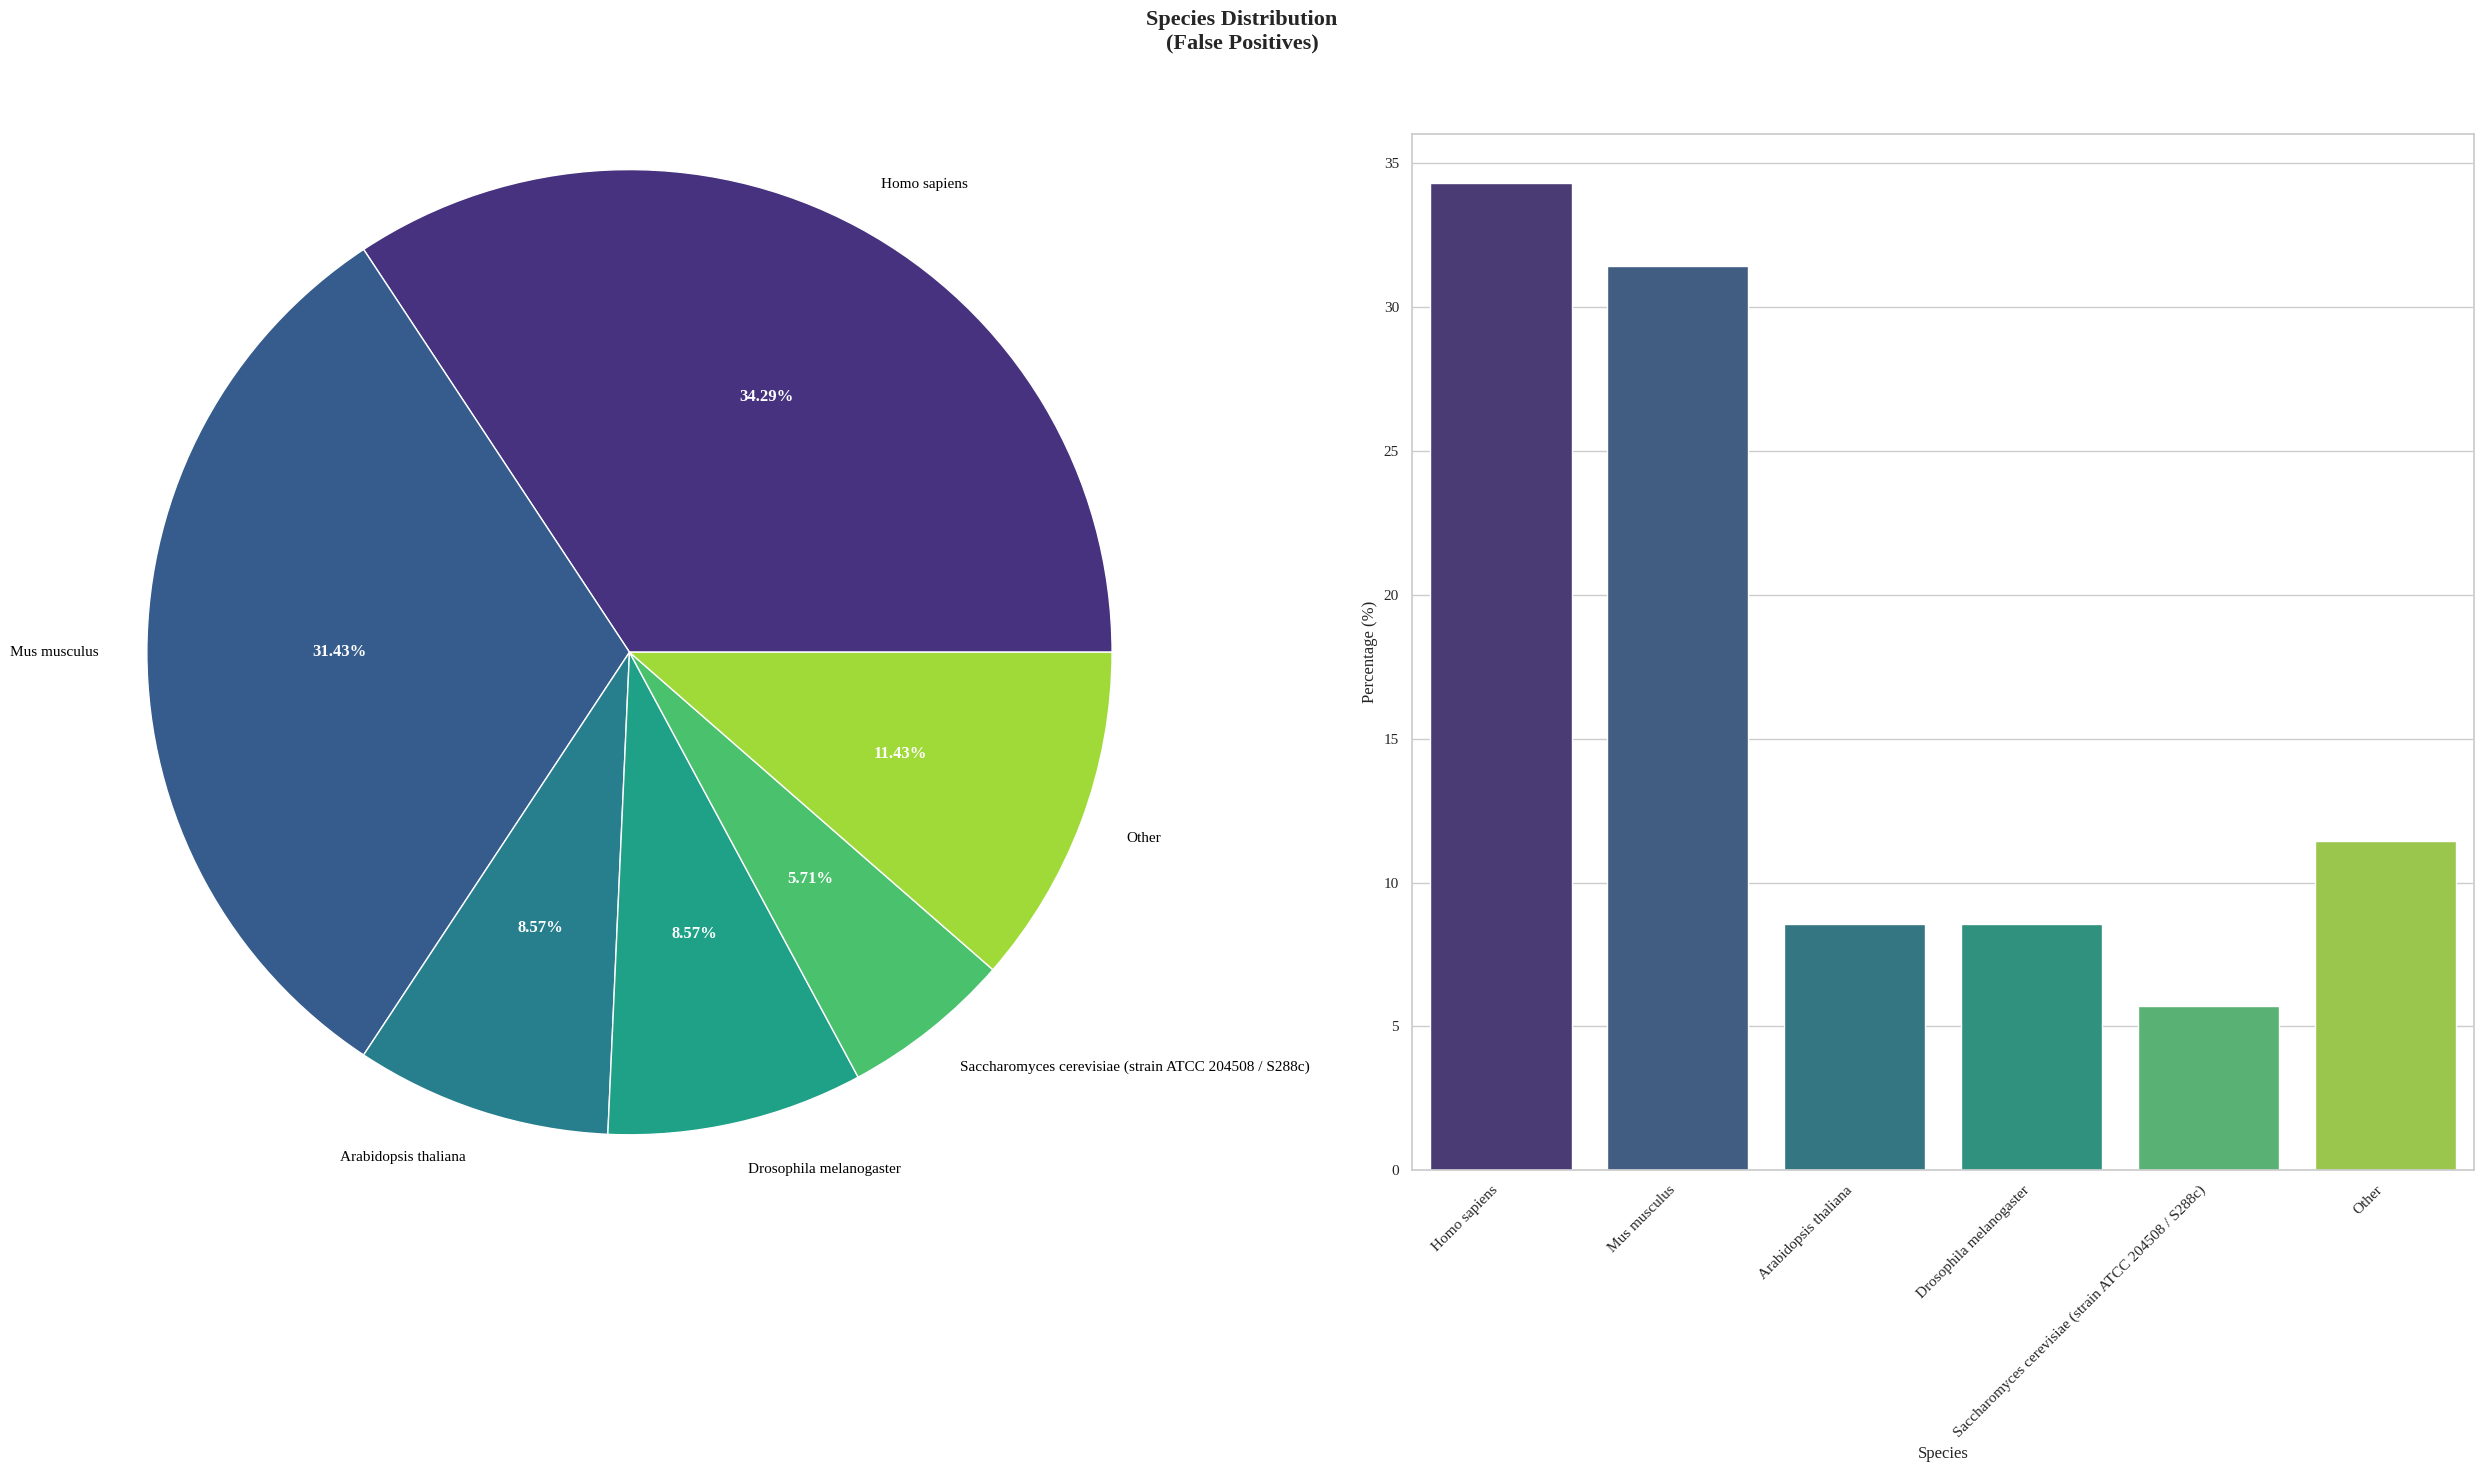

/tmp/ipython-input-800681338.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-800681338.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


<Figure size 2500x1500 with 0 Axes>

In [54]:
# Count values and percentages
fp_species = fp_meta['Species'].value_counts()
fp_percent = fp_species / fp_species.sum() * 100

# Group small categories (<= 3%) into "Other"
threshold = 3.0
small_cats = fp_percent[fp_percent <= threshold]

if len(small_cats) > 0:
    other_sum = small_cats.sum()
    # Keep large categories
    fp_species_grouped = fp_species[fp_percent > threshold].copy()
    # Add "Other" category
    fp_species_grouped["Other"] = (other_sum / 100) * fp_species.sum()
else:
    fp_species_grouped = fp_species.copy()

# Recalculate percentages after grouping
fp_percent_grouped = fp_species_grouped / fp_species_grouped.sum() * 100

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 15))
fig.suptitle("Species Distribution\n(False Positives)", fontsize=16, fontweight='bold')

# pie plot
wedges, texts, autotexts = ax1.pie(
    fp_species_grouped,
    labels=fp_species_grouped.index,
    autopct='%.2f%%'
)
ax1.axis('equal')
for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# bar plot
sns.barplot(
    x=fp_percent_grouped.index,
    y=fp_percent_grouped.values,
    ax=ax2,
    palette="viridis"
)
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Species")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 15))
fig.suptitle("Species Distribution\n(False Positives)", fontsize=16, fontweight='bold')

# pie plot
wedges, texts, autotexts = ax1.pie(
    fp_species_grouped,
    labels=fp_species_grouped.index,
    autopct='%.2f%%'
)
ax1.axis('equal')
for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# bar plot
sns.barplot(
    x=fp_percent_grouped.index,
    y=fp_percent_grouped.values,
    ax=ax2,
    palette="viridis"
)
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Species")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
plt.savefig("FP_species.png", dpi=1000, format="png")
plt.clf()

/tmp/ipython-input-4057185191.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-4057185191.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


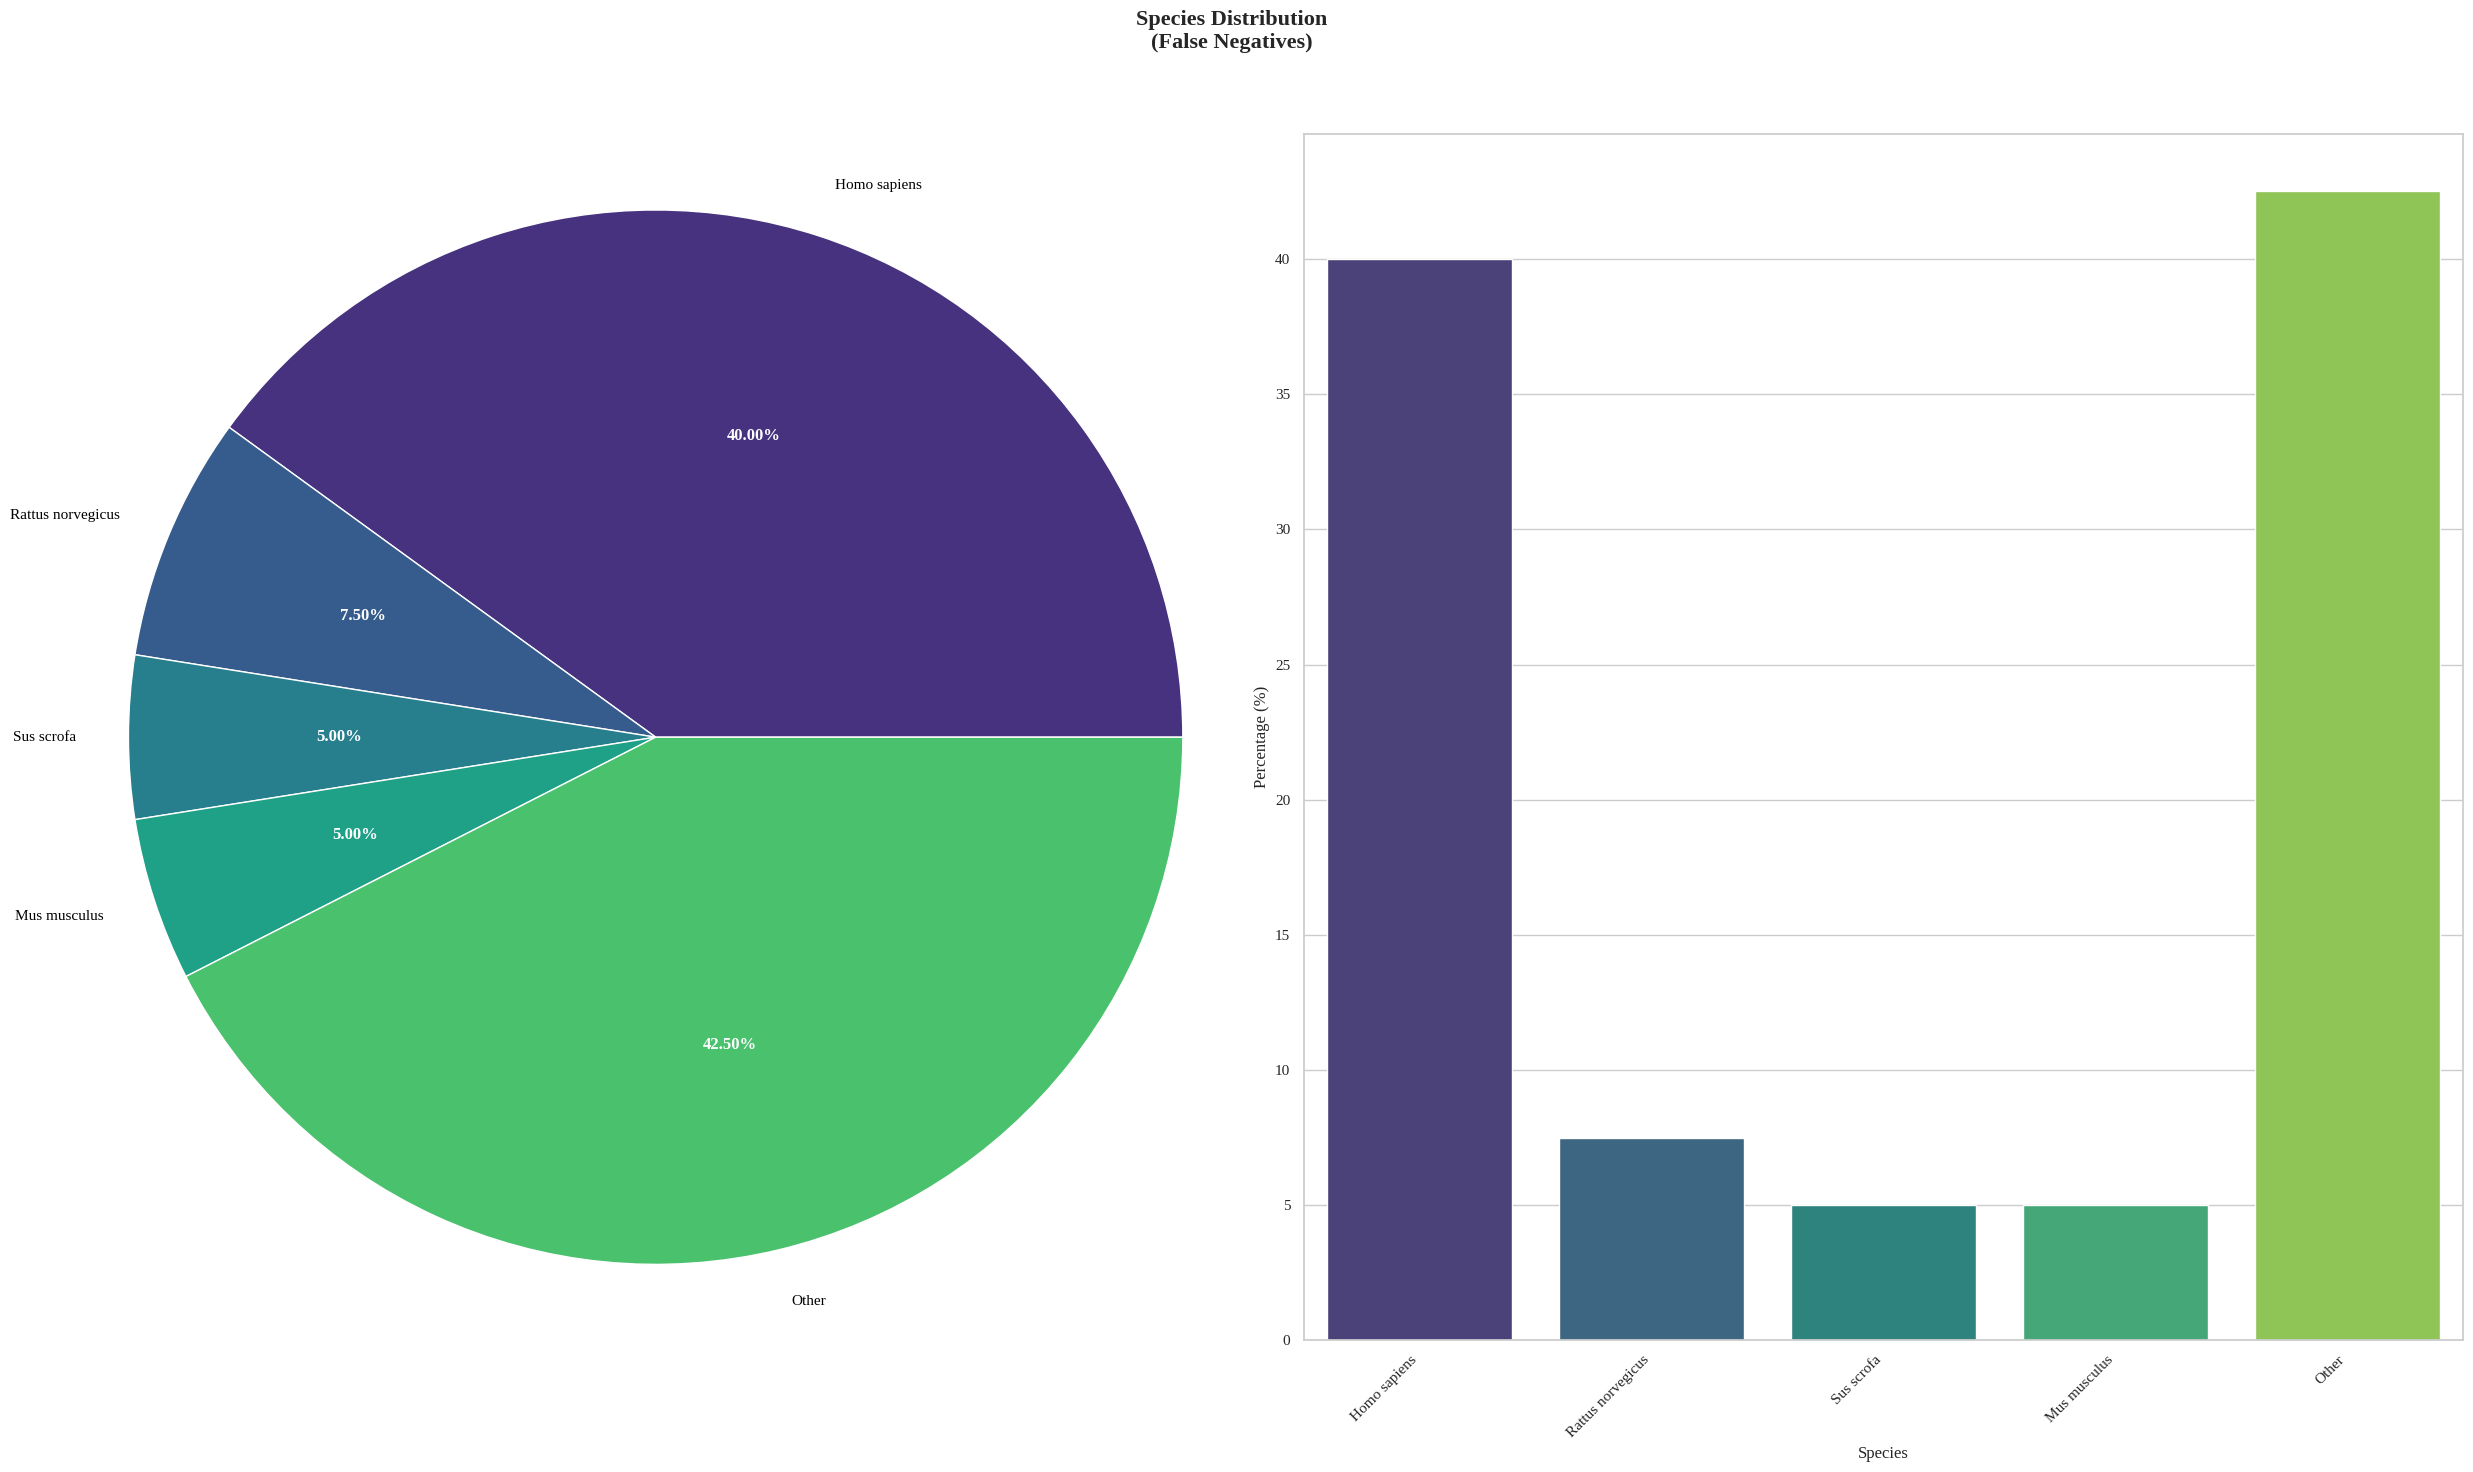

/tmp/ipython-input-4057185191.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-4057185191.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


<Figure size 2500x1500 with 0 Axes>

In [55]:
# Count values and percentages
fn_species = fn_meta['Species'].value_counts()
fn_percent = fn_species / fn_species.sum() * 100

# Group small categories (<= 3%) into "Other"
threshold = 3.0
small_cats = fn_percent[fn_percent <= threshold]

if len(small_cats) > 0:
    other_sum = small_cats.sum()
    # Keep large categories
    fn_species_grouped = fn_species[fn_percent > threshold].copy()
    # Add "Other" category
    fn_species_grouped["Other"] = (other_sum / 100) * fn_species.sum()
else:
    fn_species_grouped = fn_species.copy()

# Recalculate percentages after grouping
fn_percent_grouped = fn_species_grouped / fn_species_grouped.sum() * 100

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 15))
fig.suptitle("Species Distribution\n(False Negatives)", fontsize=16, fontweight='bold')

# pie plot
wedges, texts, autotexts = ax1.pie(
    fn_species_grouped,
    labels=fn_species_grouped.index,
    autopct='%.2f%%'
)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# bar plot
sns.barplot(
    x=fn_percent_grouped.index,
    y=fn_percent_grouped.values,
    ax=ax2,
    palette="viridis"
)
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Species")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
#plt.savefig("t_kingdom.pdf", dpi=1000, format="pdf")
#plt.clf()
# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 15))
fig.suptitle("Species Distribution\n(False Negatives)", fontsize=16, fontweight='bold')

# pie plot
wedges, texts, autotexts = ax1.pie(
    fn_species_grouped,
    labels=fn_species_grouped.index,
    autopct='%.2f%%'
)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# bar plot
sns.barplot(
    x=fn_percent_grouped.index,
    y=fn_percent_grouped.values,
    ax=ax2,
    palette="viridis"
)
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Species")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
plt.savefig("FN_species.png", dpi=1000, format="png")
plt.clf()

## FPR: all vs TM Helix

In [42]:
fp_tm = FP[FP['TM_Helix'] == True]
negatives = svm[svm['Class'] == 0]
fpr = len(FP['UniProt_ID']) / (len(negatives['UniProt_ID']))
fpr_tm = len(fp_tm['UniProt_ID']) / (len(negatives[negatives['TM_Helix'] == True]['UniProt_ID']))
print("FPR is overall "+str(fpr)+".\nOver false positives carrying a trans membrane domain in the first 90 residues the FPR is "+str(fpr_tm))
print("The FPR of sequences carryng a TM domain is "+str(fpr_tm/fpr)+" times the FPR over all sequences.")

FPR is overall 0.019585898153329603.
Over false positives carrying a trans membrane domain in the first 90 residues the FPR is 0.07086614173228346
The FPR of sequences carryng a TM domain is 3.61822272215973 times the FPR over all sequences.


## Comparing aa Distribution of False Negatives and True Positives

In [43]:
compositions = np.zeros((len(TP["Frag_90"]), 20))
for i, seq in enumerate(TP['Frag_90']):
  compositions[i] = sequence_composition(seq)
tp_composition = np.sum(compositions, axis=0) / compositions.shape[0]

compositions = np.zeros((len(FN["Frag_90"]), 20))
for i, seq in enumerate(FN['Frag_90']):
  compositions[i] = sequence_composition(seq)
fn_composition = np.sum(compositions, axis=0) / compositions.shape[0]


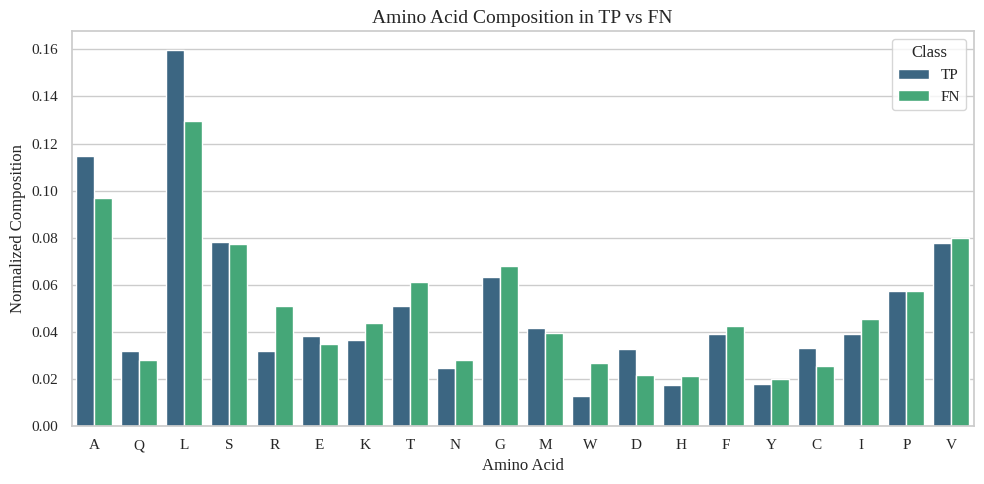

<Figure size 1000x500 with 0 Axes>

In [44]:
aa_order = list("AQLSREKTNGMWDHFYCIPV")

data = pd.DataFrame({
    'AA': np.tile(aa_order, 2),
    'Composition': np.concatenate([tp_composition, fn_composition]),
    'Type': ['TP'] * 20 + ['FN'] * 20
})

# plot grouped barplot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=data, x='AA', y='Composition', hue='Type', palette='viridis')
ax.set_xlabel("Amino Acid", fontsize=12)
ax.set_ylabel("Normalized Composition", fontsize=12)
ax.set_title("Amino Acid Composition in TP vs FN", fontsize=14)
ax.legend(title='Class', loc='upper right')
plt.tight_layout()
plt.show()
# plot grouped barplot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=data, x='AA', y='Composition', hue='Type', palette='viridis')
ax.set_xlabel("Amino Acid", fontsize=12)
ax.set_ylabel("Normalized Composition", fontsize=12)
ax.set_title("Amino Acid Composition in TP vs FN", fontsize=14)
ax.legend(title='Class', loc='upper right')
plt.tight_layout()
plt.savefig("AA_Comp_TPvsFN.png", dpi = 1000, format = "png")
plt.clf()

## Comparing FN vs TP with respect to the other features

In [45]:
fn_seqs = FN['Frag_90']
tp_seqs = TP['Frag_90']
fn_ha, fn_tm, fn_a, fn_b, fn_c = extract_features(fn_seqs)
tp_ha, tp_tm, tp_a, tp_b, tp_c = extract_features(tp_seqs)

fn_features = [fn_ha, fn_tm, fn_a, fn_b, fn_c]
tp_features = [tp_ha, tp_tm, tp_a, tp_b, tp_c]

fn_normalized = []
tp_normalized = []
for f in fn_features:
  norm = np.sum(f, axis = 0) / f.shape[0]
  #norm = norm / np.max(norm)
  fn_normalized.append(norm)
  #print(np.sum(norm))
for f in tp_features:
  norm = np.sum(f, axis = 0) / f.shape[0]
  #norm = norm / np.max(norm)
  tp_normalized.append(norm)

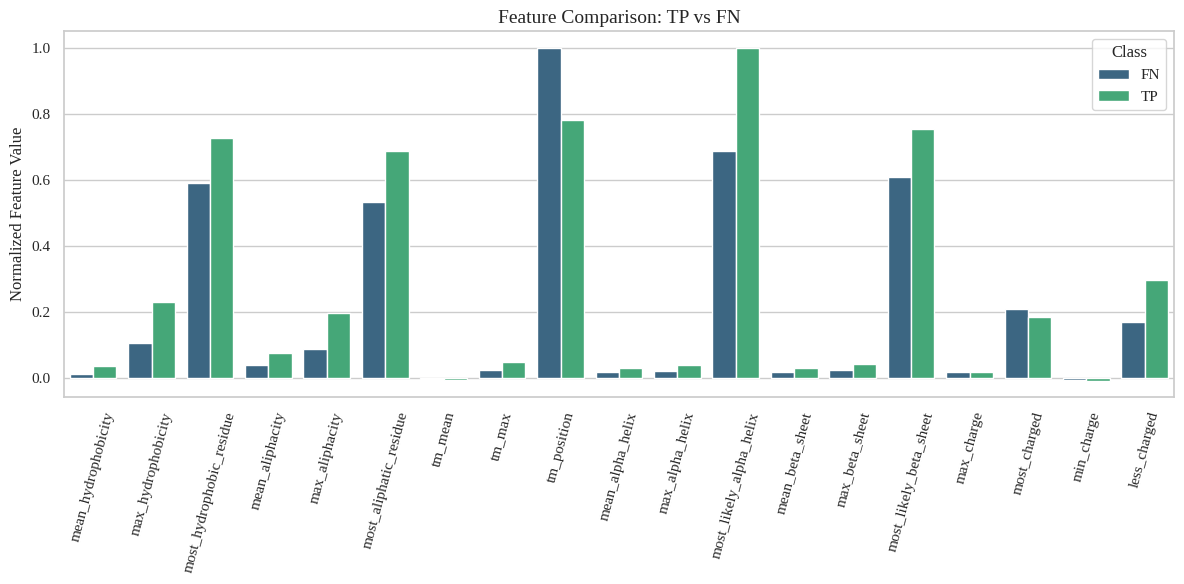

In [46]:
labels = ["mean_hydrophobicity", "max_hydrophobicity", "most_hydrophobic_residue",
  "mean_aliphacity", "max_aliphacity", "most_aliphatic_residue", # 6 hydrophobicity and aliphacity
  "tm_mean", "tm_max", "tm_position", # 3 tm propensity features
  "mean_alpha_helix", "max_alpha_helix", "most_likely_alpha_helix",
  "mean_beta_sheet", "max_beta_sheet", "most_likely_beta_sheet", # 6 accounting for SSE
  "max_charge", "most_charged", "min_charge", "less_charged" # 4 accounting for charge
  ]

fn_all = np.concatenate(fn_normalized)
fn_all = fn_all / np.max(fn_all)
tp_all = np.concatenate(tp_normalized)
tp_all = tp_all / np.max(tp_all)

df = pd.DataFrame({
    'Feature': labels * 2,
    'Value': np.concatenate([fn_all, tp_all]),
    'Type': ['FN'] * len(labels) + ['TP'] * len(labels)
})

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='Feature', y='Value', hue='Type', palette='viridis')

ax.set_xlabel("")
ax.set_ylabel("Normalized Feature Value", fontsize=12)
ax.set_title("Feature Comparison: TP vs FN", fontsize=14)
ax.tick_params(axis='x', rotation=75)
ax.legend(title='Class')

plt.tight_layout()
plt.show()

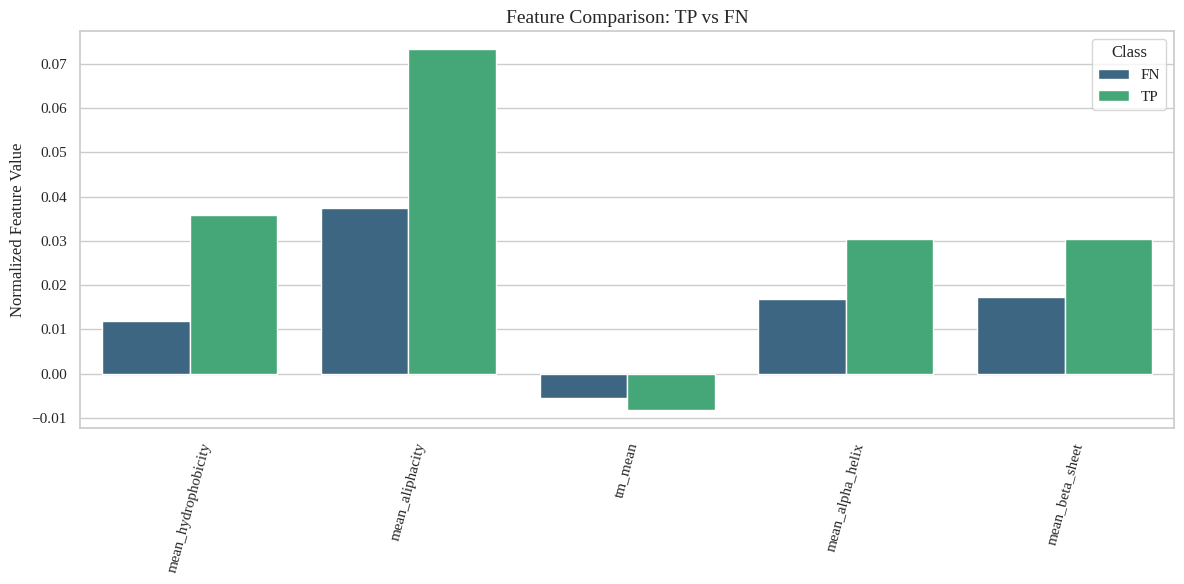

In [47]:
labels = ["mean_hydrophobicity",
  "mean_aliphacity",
  "tm_mean",
  "mean_alpha_helix",
  "mean_beta_sheet",
  ]

# Filter the already normalized fn_all and tp_all arrays to get only the mean features
fn_all_filtered = fn_all[[0, 3, 6, 9, 12]]
tp_all_filtered = tp_all[[0, 3, 6, 9, 12]]

df = pd.DataFrame({
    'Feature': labels * 2,
    'Value': np.concatenate([fn_all_filtered, tp_all_filtered]),
    'Type': ['FN'] * len(labels) + ['TP'] * len(labels)
})

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='Feature', y='Value', hue='Type', palette='viridis')

ax.set_xlabel("")
ax.set_ylabel("Normalized Feature Value", fontsize=12)
ax.set_title("Feature Comparison: TP vs FN", fontsize=14)
ax.tick_params(axis='x', rotation=75)
ax.legend(title='Class')

plt.tight_layout()
plt.show()

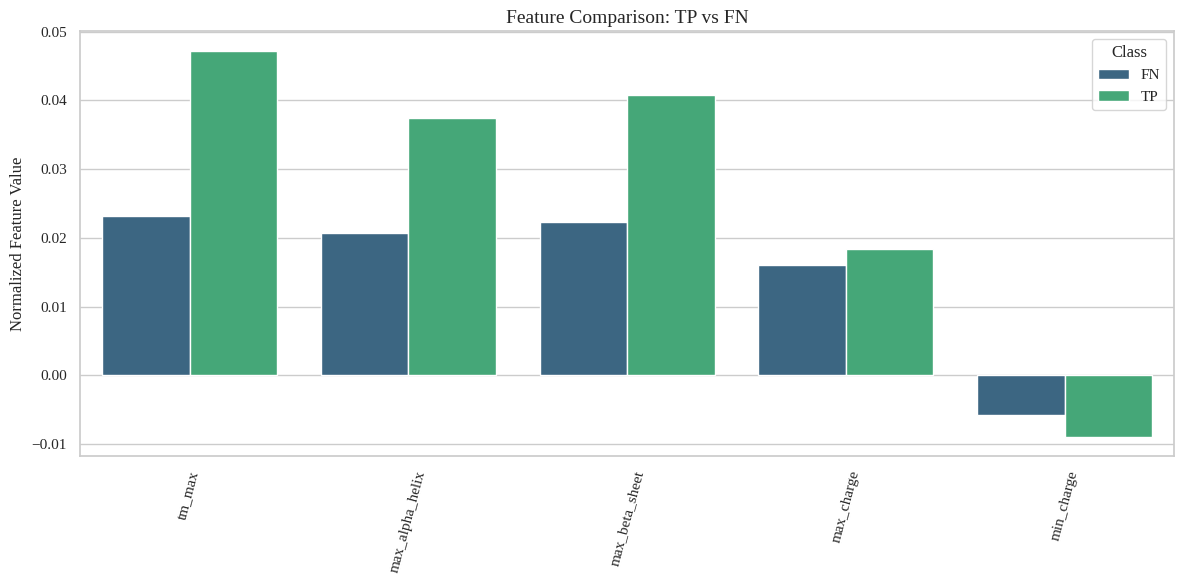

In [48]:
labels = ["tm_max",
          "max_alpha_helix",
          "max_beta_sheet",
          "max_charge", "min_charge"
  ]

fn_all = np.concatenate(fn_normalized)
fn_all = fn_all / np.max(fn_all)
tp_all = np.concatenate(tp_normalized)
tp_all = tp_all / np.max(tp_all)

# Filter fn_all and tp_all to match the selected labels
# Indices correspond to the positions of the 'max' and 'min' features in the concatenated arrays
selected_indices = [7, 10, 13, 15, 17]
fn_all_filtered = fn_all[selected_indices]
tp_all_filtered = tp_all[selected_indices]

df = pd.DataFrame({
    'Feature': labels * 2,
    'Value': np.concatenate([fn_all_filtered, tp_all_filtered]),
    'Type': ['FN'] * len(labels) + ['TP'] * len(labels)
})

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='Feature', y='Value', hue='Type', palette='viridis')

ax.set_xlabel("")
ax.set_ylabel("Normalized Feature Value", fontsize=12)
ax.set_title("Feature Comparison: TP vs FN", fontsize=14)
ax.tick_params(axis='x', rotation=75)
ax.legend(title='Class')

plt.tight_layout()
plt.show()

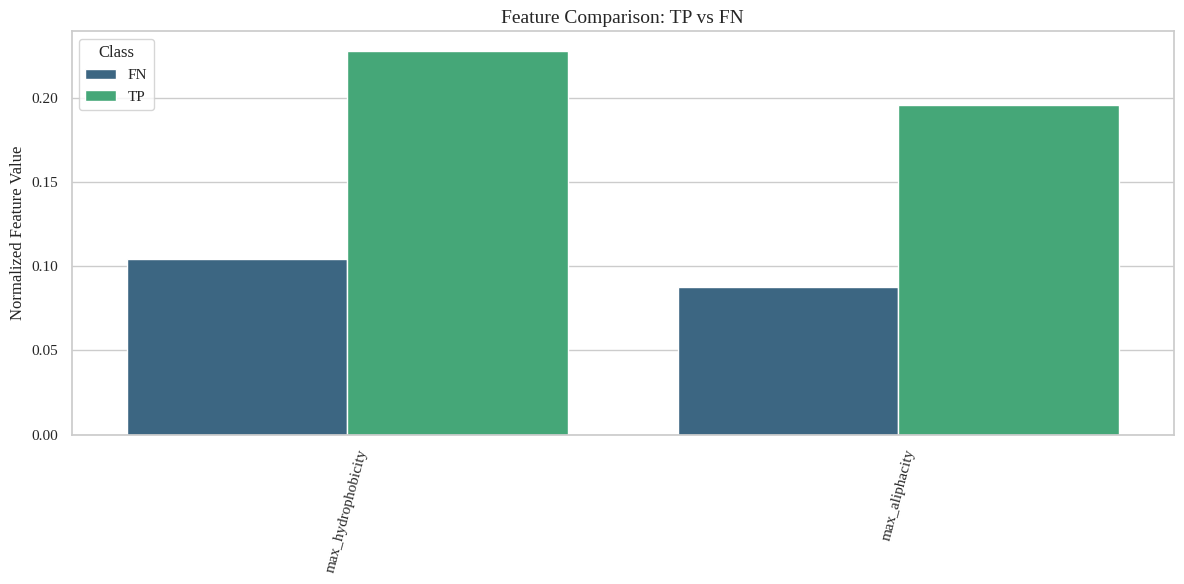

In [49]:
labels = ["max_hydrophobicity",
          "max_aliphacity"]

fn_all = np.concatenate(fn_normalized)
fn_all = fn_all / np.max(fn_all)
tp_all = np.concatenate(tp_normalized)
tp_all = tp_all / np.max(tp_all)

# Select only the features specified in 'labels'
selected_indices = [1, 4] # Indices for max_hydrophobicity and max_aliphacity
fn_all_filtered = fn_all[selected_indices]
tp_all_filtered = tp_all[selected_indices]

df = pd.DataFrame({
    'Feature': labels * 2,
    'Value': np.concatenate([fn_all_filtered, tp_all_filtered]),
    'Type': ['FN'] * len(labels) + ['TP'] * len(labels)
})

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='Feature', y='Value', hue='Type', palette='viridis')

ax.set_xlabel("")
ax.set_ylabel("Normalized Feature Value", fontsize=12)
ax.set_title("Feature Comparison: TP vs FN", fontsize=14)
ax.tick_params(axis='x', rotation=75)
ax.legend(title='Class')

plt.tight_layout()
plt.show()

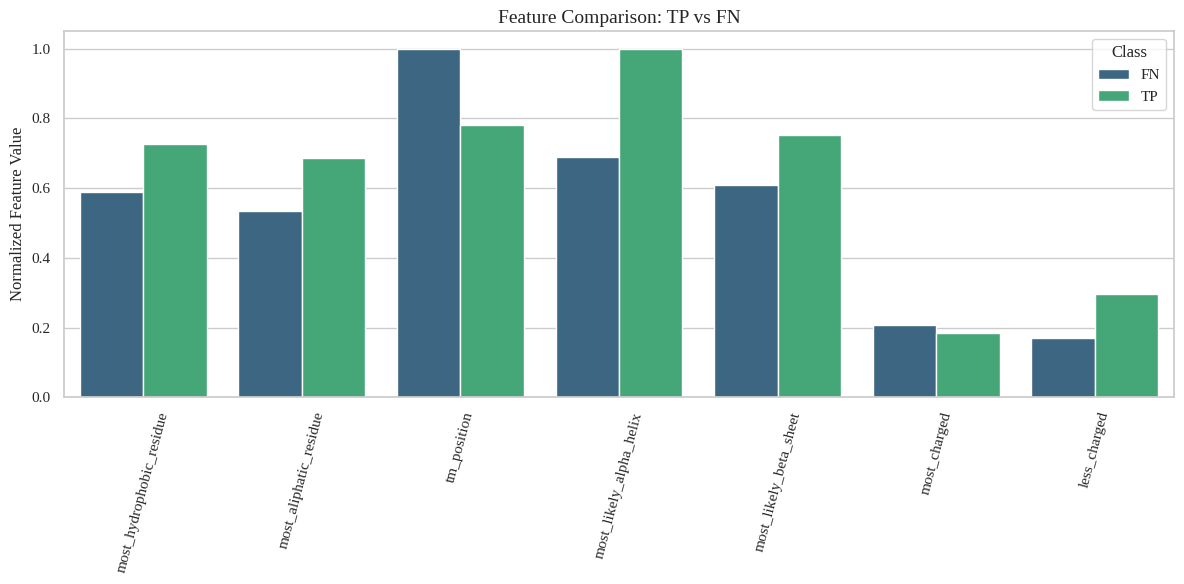

In [50]:
labels = ["most_hydrophobic_residue",
  "most_aliphatic_residue", # 6 hydrophobicity and aliphacity
  "tm_position", # 3 tm propensity features
  "most_likely_alpha_helix",
  "most_likely_beta_sheet", # 6 accounting for SSE
  "most_charged", "less_charged" # 4 accounting for charge
  ]

fn_all = np.concatenate(fn_normalized)
fn_all = fn_all / np.max(fn_all)
tp_all = np.concatenate(tp_normalized)
tp_all = tp_all / np.max(tp_all)

# Select only the features specified in 'labels'
# Indices correspond to the positions of these features in the concatenated fn_all/tp_all
selected_indices = [2, 5, 8, 11, 14, 16, 18]
fn_all_filtered = fn_all[selected_indices]
tp_all_filtered = tp_all[selected_indices]

df = pd.DataFrame({
    'Feature': labels * 2,
    'Value': np.concatenate([fn_all_filtered, tp_all_filtered]),
    'Type': ['FN'] * len(labels) + ['TP'] * len(labels)
})

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='Feature', y='Value', hue='Type', palette='viridis')

ax.set_xlabel("")
ax.set_ylabel("Normalized Feature Value", fontsize=12)
ax.set_title("Feature Comparison: TP vs FN", fontsize=14)
ax.tick_params(axis='x', rotation=75)
ax.legend(title='Class')

plt.tight_layout()
plt.show()

## Saving all plots

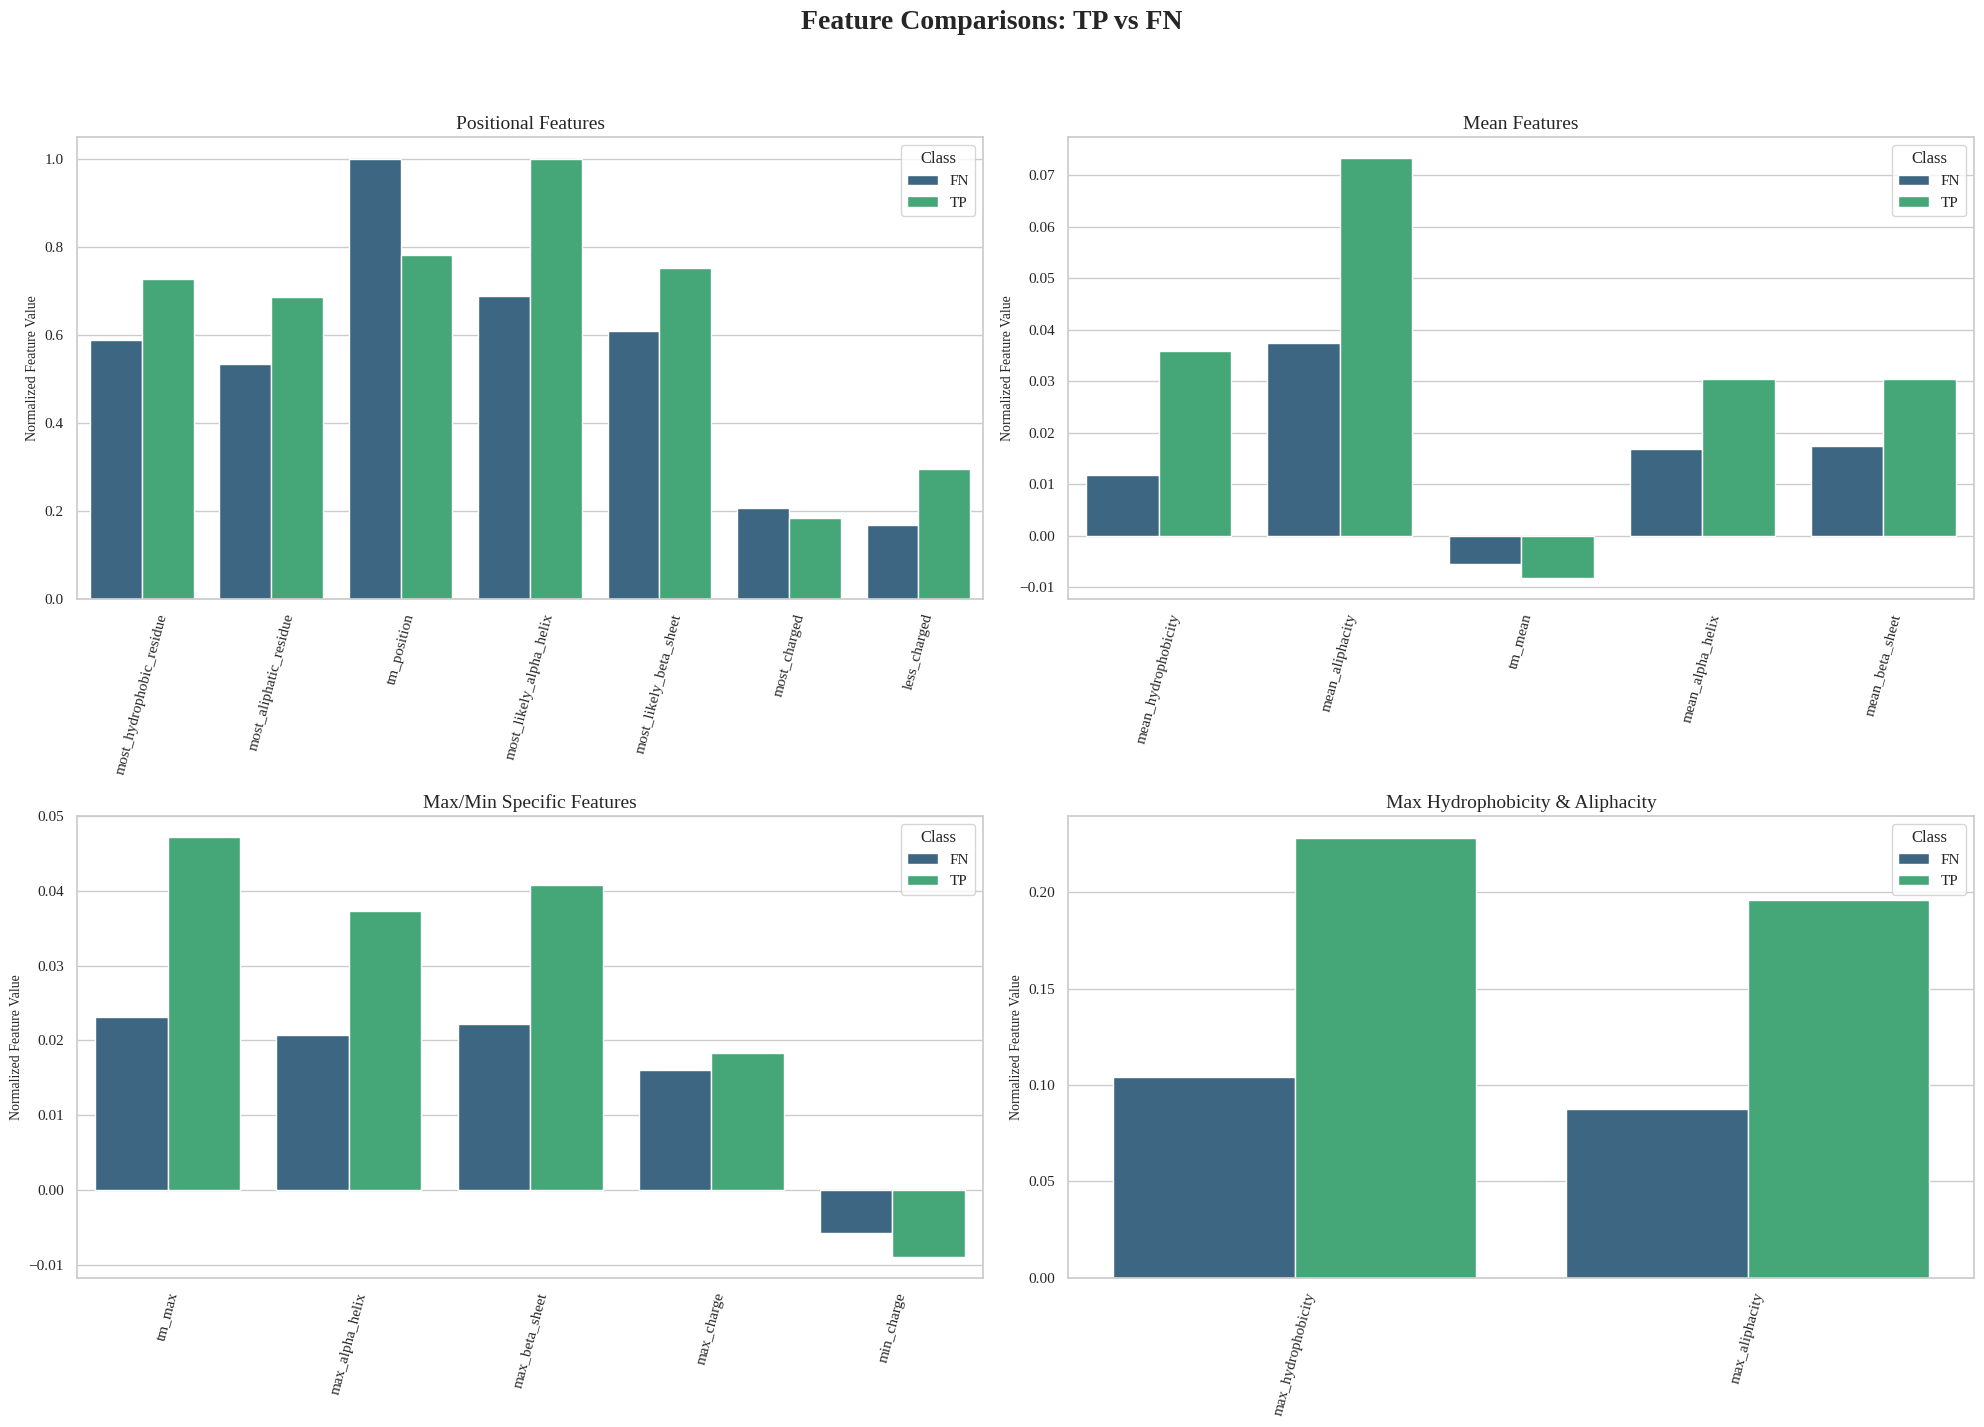

<Figure size 640x480 with 0 Axes>

In [51]:
# Create a single figure with 2 rows and 2 columns for subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 15)) # Adjust figsize as needed for clarity
fig.suptitle("Feature Comparisons: TP vs FN", fontsize=20, fontweight='bold')

# Plot 1: Positional Features Comparison
labels_plot1 = ["most_hydrophobic_residue", "most_aliphatic_residue",
                "tm_position", "most_likely_alpha_helix",
                "most_likely_beta_sheet", "most_charged", "less_charged"]
selected_indices_plot1 = [2, 5, 8, 11, 14, 16, 18]

df_plot1 = pd.DataFrame({
    'Feature': labels_plot1 * 2,
    'Value': np.concatenate([fn_all[selected_indices_plot1], tp_all[selected_indices_plot1]]),
    'Type': ['FN'] * len(labels_plot1) + ['TP'] * len(labels_plot1)
})
sns.barplot(data=df_plot1, x='Feature', y='Value', hue='Type', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Normalized Feature Value", fontsize=10)
axes[0, 0].set_title("Positional Features", fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=75)
axes[0, 0].legend(title='Class')

# Plot 2: Mean Features Comparison
labels_plot2 = ["mean_hydrophobicity", "mean_aliphacity", "tm_mean",
                "mean_alpha_helix", "mean_beta_sheet"]
selected_indices_plot2 = [0, 3, 6, 9, 12]

df_plot2 = pd.DataFrame({
    'Feature': labels_plot2 * 2,
    'Value': np.concatenate([fn_all[selected_indices_plot2], tp_all[selected_indices_plot2]]),
    'Type': ['FN'] * len(labels_plot2) + ['TP'] * len(labels_plot2)
})
sns.barplot(data=df_plot2, x='Feature', y='Value', hue='Type', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Normalized Feature Value", fontsize=10)
axes[0, 1].set_title("Mean Features", fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=75)
axes[0, 1].legend(title='Class')

# Plot 3: Max/Min Specific Features Comparison
labels_plot3 = ["tm_max", "max_alpha_helix", "max_beta_sheet",
                "max_charge", "min_charge"]
selected_indices_plot3 = [7, 10, 13, 15, 17]

df_plot3 = pd.DataFrame({
    'Feature': labels_plot3 * 2,
    'Value': np.concatenate([fn_all[selected_indices_plot3], tp_all[selected_indices_plot3]]),
    'Type': ['FN'] * len(labels_plot3) + ['TP'] * len(labels_plot3)
})
sns.barplot(data=df_plot3, x='Feature', y='Value', hue='Type', palette='viridis', ax=axes[1, 0])
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Normalized Feature Value", fontsize=10)
axes[1, 0].set_title("Max/Min Specific Features", fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=75)
axes[1, 0].legend(title='Class')

# Plot 4: Max Hydrophobicity and Max Aliphacity Comparison
labels_plot4 = ["max_hydrophobicity", "max_aliphacity"]
selected_indices_plot4 = [1, 4]

df_plot4 = pd.DataFrame({
    'Feature': labels_plot4 * 2,
    'Value': np.concatenate([fn_all[selected_indices_plot4], tp_all[selected_indices_plot4]]),
    'Type': ['FN'] * len(labels_plot4) + ['TP'] * len(labels_plot4)
})
sns.barplot(data=df_plot4, x='Feature', y='Value', hue='Type', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Normalized Feature Value", fontsize=10)
axes[1, 1].set_title("Max Hydrophobicity & Aliphacity", fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=75)
axes[1, 1].legend(title='Class')

# Adjust layout and save the combined figure
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to prevent suptitle overlap
plt.savefig("Features_TPvsFN_Combined.png", dpi=1000, format="png")
plt.show()
plt.clf()

In [56]:
!zip -r output.zip /content/
from google.colab import files
files.download("output.zip")

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.11.12/ (stored 0%)
  adding: content/.config/logs/2025.11.12/14.30.35.902193.log (deflated 56%)
  adding: content/.config/logs/2025.11.12/14.30.26.280314.log (deflated 58%)
  adding: content/.config/logs/2025.11.12/14.30.15.789373.log (deflated 58%)
  adding: content/.config/logs/2025.11.12/14.30.35.156140.log (deflated 57%)
  adding: content/.config/logs/2025.11.12/14.30.24.701531.log (deflated 86%)
  adding: content/.config/logs/2025.11.12/14.29.51.386235.log (deflated 92%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/hidden_gc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>